In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

In [5]:
df = pd.read_parquet("/home/gq11/Documents/Code/Jupiter Notebook/df_clean.parquet")

Most Downloaded Game

In [8]:
df['mean_estimated_owners'] = df['estimated_owners'].str.split(' - ', expand=True).astype(float).mean(axis=1)

In [10]:
df2 = df.copy()

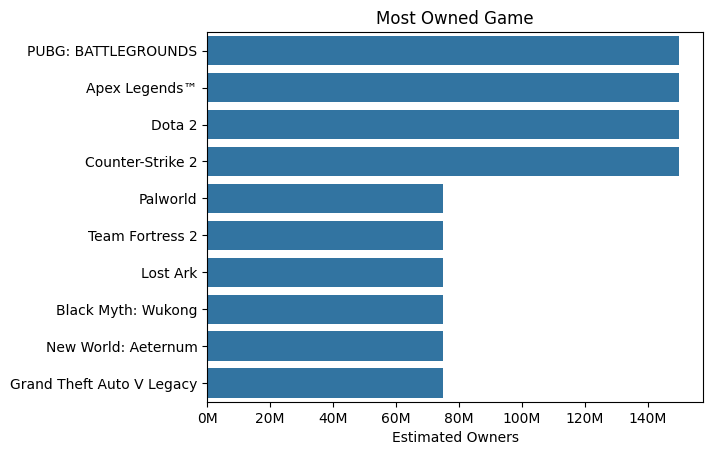

In [30]:
plot = df2[['name', 'mean_estimated_owners']].sort_values(by='mean_estimated_owners', ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(data=plot, x='mean_estimated_owners', y='name')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M'))
ax.set_xlabel("Estimated Owners")
ax.set_ylabel("")
ax.set_title("Most Owned Game")
plt.show()


Number of Games Released on Steam by Year

In [32]:
df['release_year'] = df['release_date'].dt.year

In [34]:
df2 = df.copy()
df2 = df2[(df2['release_year'] > 2003) & (df2['release_year'] < 2026)].sort_values(by='release_year')

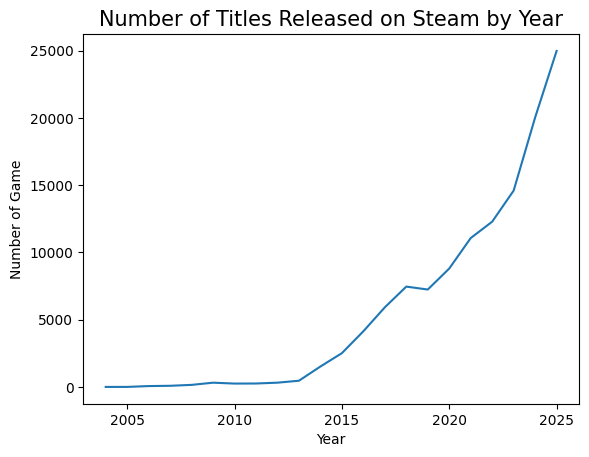

In [36]:
df2.groupby('release_year').size().plot()
plt.xlabel('Year')
plt.ylabel('Number of Game')
plt.title('Number of Titles Released on Steam by Year', fontsize=15)
plt.show()

Video Game Genres Analysis:

In [37]:
df2 = df.copy()

In [38]:
df2 = df2[['appID', 'mean_estimated_owners', 'genres']].explode('genres')

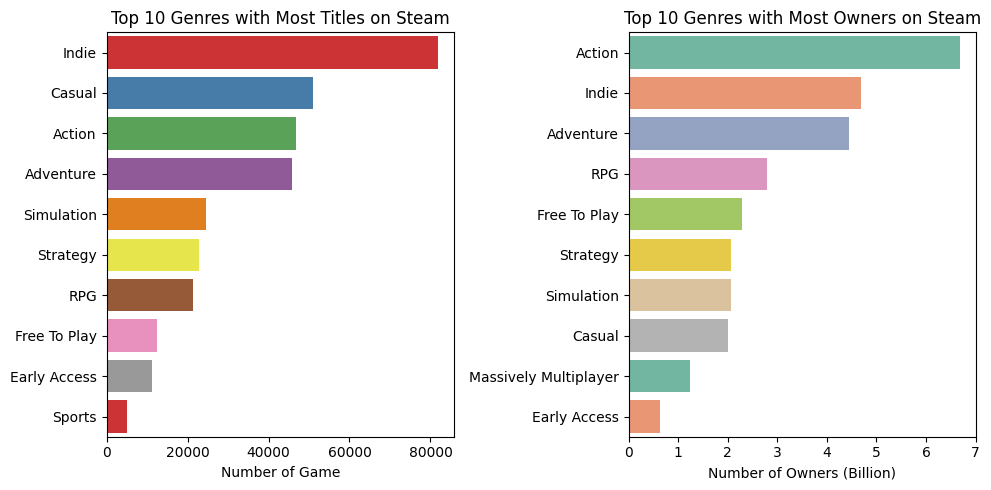

In [69]:
plot1 = df2['genres'].value_counts().head(10)
plot2 = df2.groupby('genres')['mean_estimated_owners'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(1,2, figsize=(10,5))

sns.barplot(x=plot1.values, y=plot1.index, hue=plot1.index, palette="Set1", ax=ax[0])
ax[0].set_xlabel('Number of Game')
ax[0].set_ylabel('')
ax[0].set_title('Top 10 Genres with Most Titles on Steam')

sns.barplot(x=plot2.values, y=plot2.index, hue=plot2.index, palette="Set2", ax=ax[1])
ax[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-9:.0f}'))
ax[1].set_xlabel('Number of Owners (Billion)')
ax[1].set_ylabel('')
ax[1].set_title('Top 10 Genres with Most Owners on Steam')

fig.tight_layout()
plt.show()


How have popular game genres changed over time?

In [105]:
df2 = df.copy()

In [106]:
df2 = df2[(df2['release_year'] > 2014) & (df2['release_year'] < 2026)].sort_values(by='release_year')
df2 = df2[['appID', 'mean_estimated_owners', 'genres', 'release_year']].explode('genres')

In [107]:
plot3 = df2.pivot_table( index='release_year', columns='genres', aggfunc='size')[plot1.index]

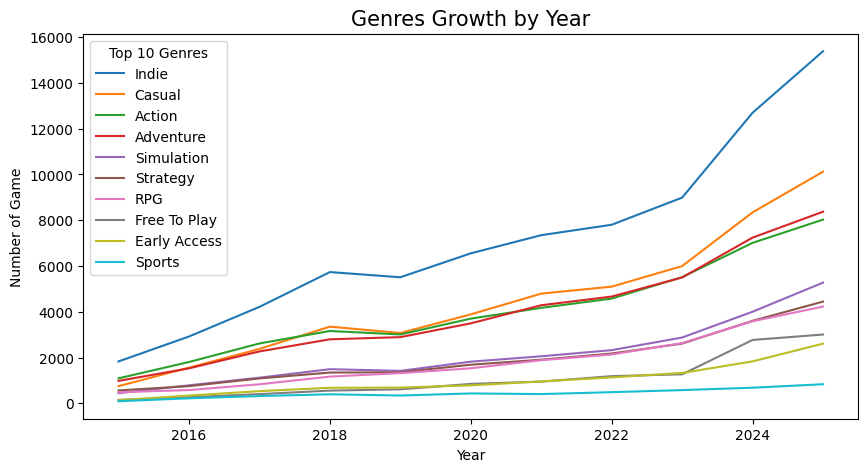

In [109]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=plot3, palette="tab10", dashes=False)
plt.xlabel('Year')
plt.ylabel('Number of Game')
plt.legend(title="Top 10 Genres")
plt.title('Genres Growth by Year', fontsize=15)
plt.show()